In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mtb
import seaborn as sns

In [2]:
movies = pd.read_csv('C:\ML_PROJECT\ml-latest-small\movies.csv')
ratings = pd.read_csv(r'C:\ML_PROJECT\ml-latest-small\ratings.csv')
tags = pd.read_csv(r'C:\ML_PROJECT\ml-latest-small\tags.csv')


<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10032\2995972342.py:1: SyntaxWarning: invalid escape sequence '\M'
  movies = pd.read_csv('C:\ML_PROJECT\ml-latest-small\movies.csv')


In [3]:
movies.head()


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


***Since links go to external website.It doesn't show any difference in the data set.As the target value doesn't depend on the link.So we are not taking the links.***

In [6]:
merged = movies.merge(ratings,on='movieId',how='left') \
               .merge(tags,on='movieId',how='left')


In [7]:
merged.head()

,movieId,title,genres,userId_x,rating,timestamp_x,userId_y,tag,timestamp_y
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1.0,4.0,964982703.0,336.0,pixar,1.139046e+09
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1.0,4.0,964982703.0,474.0,pixar,1.137207e+09
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1.0,4.0,964982703.0,567.0,fun,1.525286e+09
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5.0,4.0,847434962.0,336.0,pixar,1.139046e+09
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5.0,4.0,847434962.0,474.0,pixar,1.137207e+09


In [8]:
merged.tail()

,movieId,title,genres,userId_x,rating,timestamp_x,userId_y,tag,timestamp_y
285778,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy,184.0,4.0,1.537109e+09,NaN,NaN,NaN
285779,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy,184.0,3.5,1.537110e+09,NaN,NaN,NaN
285780,193585,Flint (2017),Drama,184.0,3.5,1.537110e+09,NaN,NaN,NaN
285781,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation,184.0,3.5,1.537110e+09,NaN,NaN,NaN
285782,193609,Andrew Dice Clay: Dice Rules (1991),Comedy,331.0,4.0,1.537158e+09,NaN,NaN,NaN


In [9]:
merged.shape

(285783, 9)

In [10]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285783 entries, 0 to 285782
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   movieId      285783 non-null  int64  
 1   title        285783 non-null  object 
 2   genres       285783 non-null  object 
 3   userId_x     285762 non-null  float64
 4   rating       285762 non-null  float64
 5   timestamp_x  285762 non-null  float64
 6   userId_y     233234 non-null  float64
 7   tag          233234 non-null  object 
 8   timestamp_y  233234 non-null  float64
dtypes: float64(5), int64(1), object(3)
memory usage: 19.6+ MB


In [11]:
merged['genres'].value_counts().head()


genres
Comedy|Crime|Drama|Thriller    56864
Action|Crime|Drama|Thriller    17120
Action|Adventure|Sci-Fi        12778
Comedy                         10334
Drama                           9281
Name: count, dtype: int64

In [12]:
merged.describe()

,movieId,userId_x,rating,timestamp_x,userId_y,timestamp_y
count,285783.000000,285762.000000,285762.000000,2.857620e+05,233234.000000,2.332340e+05
mean,14927.663741,313.894279,3.841270,1.214707e+09,470.681354,1.384754e+09
std,31402.673519,179.451387,1.020798,2.233730e+08,153.324249,1.534705e+08
min,1.000000,1.000000,0.500000,8.281246e+08,2.000000,1.137179e+09
25%,296.000000,160.000000,3.000000,1.019133e+09,424.000000,1.242494e+09
50%,1721.000000,314.000000,4.000000,1.211377e+09,477.000000,1.457901e+09
75%,5673.000000,465.000000,4.500000,1.445346e+09,599.000000,1.498457e+09
max,193609.000000,610.000000,5.000000,1.537799e+09,610.000000,1.537099e+09


In [13]:
merged.isnull().sum()

movieId            0
title              0
genres             0
userId_x          21
rating            21
timestamp_x       21
userId_y       52549
tag            52549
timestamp_y    52549
dtype: int64

In [14]:
merged.duplicated().sum()

np.int64(0)

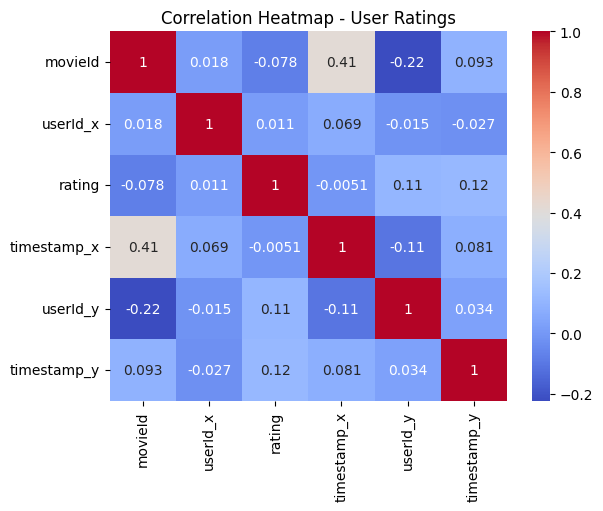

In [15]:
sns.heatmap(merged.corr(numeric_only=True), annot=True, cmap="coolwarm")
mtb.title("Correlation Heatmap - User Ratings")
mtb.show()

**Here there is no major correaltion between any two variables.Only leas or -ve correlation between them.**

<Axes: xlabel='rating'>

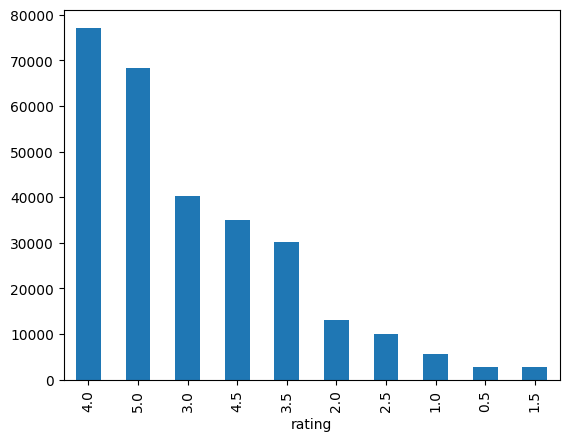

In [16]:
merged['rating'].value_counts().plot(kind='bar')


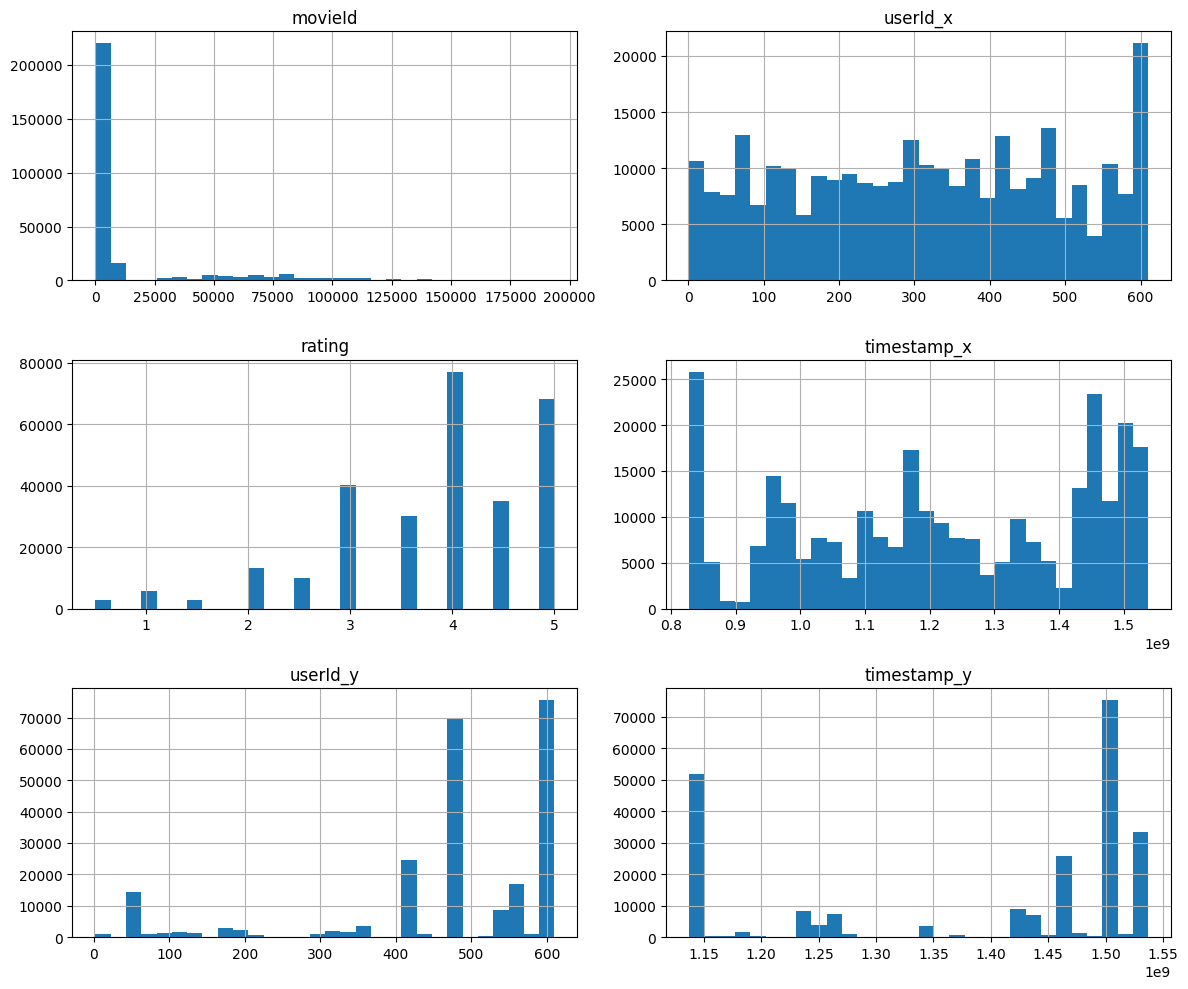

In [17]:
merged.hist(figsize=(12, 10), bins=30)
mtb.tight_layout()
mtb.show()


<Axes: xlabel='rating', ylabel='Density'>

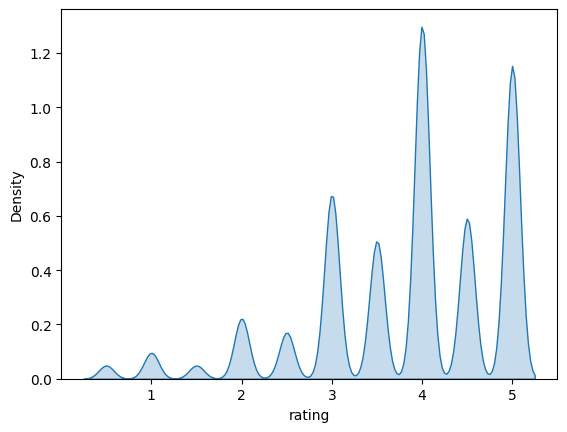

In [18]:
sns.kdeplot(data=merged, x='rating', fill=True)   


In [20]:
merged['genres'].value_counts().head()


genres
Comedy|Crime|Drama|Thriller    56864
Action|Crime|Drama|Thriller    17120
Action|Adventure|Sci-Fi        12778
Comedy                         10334
Drama                           9281
Name: count, dtype: int64

In [21]:
merged = merged.drop_duplicates()
merged['rating'] = merged['rating'].fillna(merged['rating'].mean())

In [22]:
merged['userId_x'] = merged['userId_x'].fillna(merged['userId_x'].mean())



In [ ]:
merged.isnull().sum()

movieId            0
title              0
genres             0
userId_x           0
rating             0
timestamp_x       21
userId_y       52549
tag            52549
timestamp_y    52549
dtype: int64

In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mode')
mer_imputed = imputer.fit_transform(merged)
mer_imputed


In [24]:
merged.head()

,movieId,title,genres,userId_x,rating,timestamp_x,userId_y,tag,timestamp_y
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1.0,4.0,964982703.0,336.0,pixar,1.139046e+09
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1.0,4.0,964982703.0,474.0,pixar,1.137207e+09
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1.0,4.0,964982703.0,567.0,fun,1.525286e+09
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5.0,4.0,847434962.0,336.0,pixar,1.139046e+09
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5.0,4.0,847434962.0,474.0,pixar,1.137207e+09


In [25]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285783 entries, 0 to 285782
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   movieId      285783 non-null  int64  
 1   title        285783 non-null  object 
 2   genres       285783 non-null  object 
 3   userId_x     285783 non-null  float64
 4   rating       285783 non-null  float64
 5   timestamp_x  285762 non-null  float64
 6   userId_y     233234 non-null  float64
 7   tag          233234 non-null  object 
 8   timestamp_y  233234 non-null  float64
dtypes: float64(5), int64(1), object(3)
memory usage: 19.6+ MB
